In [17]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [18]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [19]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix
R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
Vinc = E0*np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector
Zmat = Zs * Lmat # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = -np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj) + obj0 # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [29]:
# Assuming Ndes is OP.BF.nUnknowns and is an odd integer
k = (Ndes - 1) // 2

# 1. Upper block: Identity matrix of size (k + 1)
upper = np.eye(k + 1)

# 2. Lower block: Flipped identity of size k, followed by a column of zeros
# np.fliplr(np.eye(k)) creates the anti-diagonal matrix
lower_left = np.fliplr(np.eye(k))
lower_right = np.zeros((k, 1))
lower = np.hstack([lower_left, lower_right])

# 3. Vertically stack them to create C
C = np.vstack([upper, lower])
C = np.eye(Ndes) # skip transformation for testing purposes

# lossy matrix Cholesky factorization
Lchol = np.linalg.cholesky(C.conj().T @Lmat @ C).conj().T

# Mfactor = C @ np.linalg.inv(Lchol)
Mfactor = np.eye(Ndes) # skip transformation for testing purposes
# Mfactor = C

Vincf = Mfactor.conj().T @ Vinc
Ztotf = Mfactor.conj().T @ Ztot @ Mfactor
Z0f = Mfactor.conj().T @ Z0 @ Mfactor
Zmatf = Mfactor.conj().T @ Zmat @ Mfactor
Objf = Mfactor.conj().T @ Obj @ Mfactor
objf = Mfactor.conj().T @ obj
obj0f = obj0

Nfac = Z0f.shape[0]
iVec = np.zeros(Nfac, dtype=complex) # particular solution to satisfy the fixed current constraint (zero for now, can be used to satisfy a fixed current constraint by setting the iBFfixed row to np.linalg.solve(Z11, Vinc1) and the transformation matrix to have -np.linalg.solve(Z11, Z12) in the iBFfixed row)

In [30]:
# translate QCQP matrices to Dolphindes notation
Umat = 1j * Ztotf.conj() # Dolphindes U matrix
eVec = -1j*Vincf.conj() / 2 # Dolphindes e vector
Bmat = Objf # quadratic objective matrix
bVec = objf # linear objective vector
beta = obj0f # constant objective term

In [56]:
# preconditioner for projection constraints
G0 = Z0f # Green's function matrix
D = np.diag(np.diag(Z0f)) # Green's matrix diagonal
X = np.linalg.inv(Zmatf) # material admittance matrix
H0 = G0 - D
Y = np.linalg.solve(np.eye(Nfac) + X @ D, X)
iVec = X @ Vincf

S = np.eye(Nfac) + Y @ H0 # preconditioner matrix for projection constraints
q = -Y @ G0 @ iVec
p = q + S @ iVec

Sinv = np.linalg.inv(S)

P0 = Sinv @ Ztotf

sVec = Sinv @ q
tVec = sVec + iVec
Vtest = Ztotf @ tVec
print(f"voltage error: {np.max(np.abs(Vtest - Vincf))/np.max(np.abs(Vincf)):.2e}")

print(f"asymmetric error of preconditioner: {np.linalg.norm(S-S.T, ord='fro')/np.linalg.norm(S, ord='fro'):.2e}")

obj0p = obj0f
objp = objf
Objp = Objf

Ptr0 = -np.real(tVec.conj().T @ Objp @ tVec) + 2*np.real(tVec.conj().T @ objp) + obj0p
print(f"objective error: {np.abs(Ptr0 - Pfull)/np.abs(Pfull):.2e}")


realPowerConstraint = np.real(-tVec.conj().T @ -S @ P0 @ tVec + 2*tVec.conj().T @ P0.T @ -p/2)
realPower = np.real(tVec.conj().T @ S @ P0 @ tVec)

imagPowerConstraint = np.real(-tVec.conj().T @ -S @ (1j*P0) @ tVec + 2*tVec.conj().T @ (1j*P0).T @ -p/2)
imagPower = np.real(tVec.conj().T @ S @ (1j*P0) @ tVec)

print(f"real power error: {np.abs(realPowerConstraint)/np.abs(realPower):.2e}")
print(f"imaginary power error: {np.abs(imagPowerConstraint)/np.abs(imagPower):.2e}")    

Umat = -S
eVec = -p/2
Bmat = Objf
bVec = objf
beta = obj0f

voltage error: 1.36e-09
asymmetric error of preconditioner: 2.14e-09
objective error: 5.94e-11
real power error: 1.40e-12
imaginary power error: 1.16e-09


In [58]:
# make the Plist to contain matrices P0 and 1j*P0
Plist = [P0, 1j*P0]

Nopt = Umat.shape[0]

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec,
                             Plist, verbose = 1
                                )
# print fist elements of all inputs
# print(f"Bmat: {Bmat[0,0]}, bVec: {bVec[0]}, beta: {beta}, Umat: {Umat[0,0]}, eVec: {eVec[0] }")

t1 = time.time()
lags_init = np.zeros((2,))
# lags_init[0] = -1
lags_init[0] = -0.9881
lags_init[1] = -0.0378
# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(
    opttol=1e-12,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=30,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
print(f"bound: {result[0]:.4e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 1e-12
gradConverge: True
min_inner_iter: 10
max_restart: 30
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-0.9881 -0.0378]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 10.120932782098627
iter_num: 5, prev_fx: inf, opt_fx: 10.12093275783196, opttol: 1e-12
iter_num: 10, prev_fx: 10.12093275783196, opt_fx: 10.120932757831262, opttol: 1e-12
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 10.120932757831262
iter_num: 5, prev_fx: 10.12093275783196, opt_fx: 10.12093275783139, opttol: 1e-12
bound: 1.0121e+01, time: 0.3490414619445801s, Lagrange multipliers: [-0.98806809 -0.03777126]


In [41]:
# A is the total system matrix. Here I'm checking the minimum eigenvalue to see how PSD it is.
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimum eigenvalue: {np.min(np.real(eigenvals))}")
 
iChol = QCQP.current_xstar

Ivec = Mfactor @ iChol # optimal current distribution in original coordinates
Popt = np.real(Ivec.conj().T @ Obj @ Ivec) # optimal objective value
print(f"Optimal objective value: {Popt:.4e} W")

constraintVal = Ivec.conj().T @ (Ztot @ Ivec - Vinc)
print(f"constraint value in original coordinates: {constraintVal}")

minimum eigenvalue: 1.1567271101519918e-07
Optimal objective value: -1.0121e+01 W
constraint value in original coordinates: (40.91282122661908+0.00010963252074036589j)


In [48]:
from dolphindes.cvxopt.gcd import GCDHyperparameters
import copy
gcd_QCQP = copy.deepcopy(QCQP)

t = time.time()
opt_params = OptimizationHyperparameters(
    opttol=1e-6,                  
    gradConverge=False,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0              
)

gcd_params = GCDHyperparameters(
    gcd_tol=1e-12,                 # Keep extremely tight to prevent early exit
    max_proj_cstrt_num=40,       # CRITICAL: > 390. Safely covers all complex degrees of freedom!
    max_gcd_iter_num=100,         # Increased to give GCD enough runway to generate up to 400 constraints
    gcd_iter_period=20,            # Check for convergence every 2*Nopt iterations to give GCD enough time to generate constraints and converge
    orthonormalize=False,         # Keep OFF so complex phase information isn't scrambled
    opt_params=opt_params
)
gcd_QCQP.run_gcd(gcd_params=gcd_params)
print(f'gcd optimization took time {time.time()-t}.')

At GCD iteration #1, best dual bound found is             10.120932757831657.
max violation real: 1.98e+02, imag: 1.44e+01
min eigenvalue: 1.156727e-07
At GCD iteration #2, best dual bound found is             10.118609779958698.
max violation real: 1.47e+02, imag: 1.01e+01
min eigenvalue: 1.151400e-07
At GCD iteration #3, best dual bound found is             10.116860897251197.
max violation real: 6.53e+02, imag: 4.73e+01
min eigenvalue: 1.146791e-07
At GCD iteration #4, best dual bound found is             10.115403937248672.
max violation real: 1.03e+03, imag: 7.42e+01
min eigenvalue: 1.142401e-07
At GCD iteration #5, best dual bound found is             10.114159722175948.
max violation real: 1.19e+03, imag: 8.57e+01
min eigenvalue: 1.138113e-07
At GCD iteration #6, best dual bound found is             10.113093787235123.
max violation real: 1.15e+03, imag: 8.26e+01
min eigenvalue: 1.133908e-07
At GCD iteration #7, best dual bound found is             10.1121857759995.
max violatio

In [49]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")

minimal eigenvalue: 1.0986062355270667e-07


bound: 10.10821344653279, time: 1.0556585788726807s
min eigenvalue: 1.0986062284613997e-07


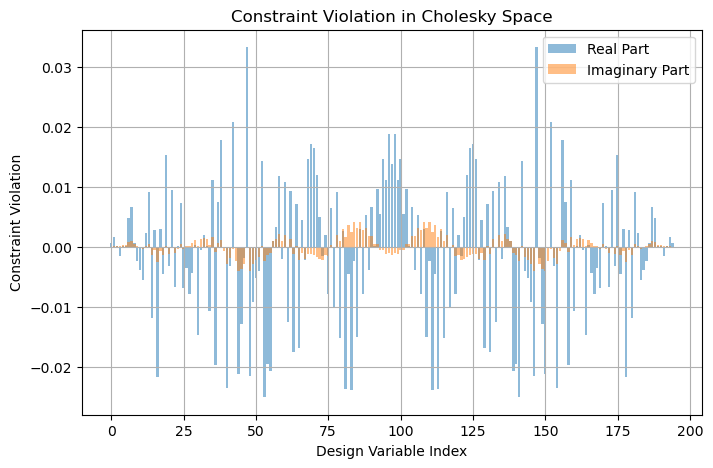

GCD primary objective: -10.10821345439289
GCD dual bound: 10.10821344653279
Objective with GCD solution: -10.10821345439289


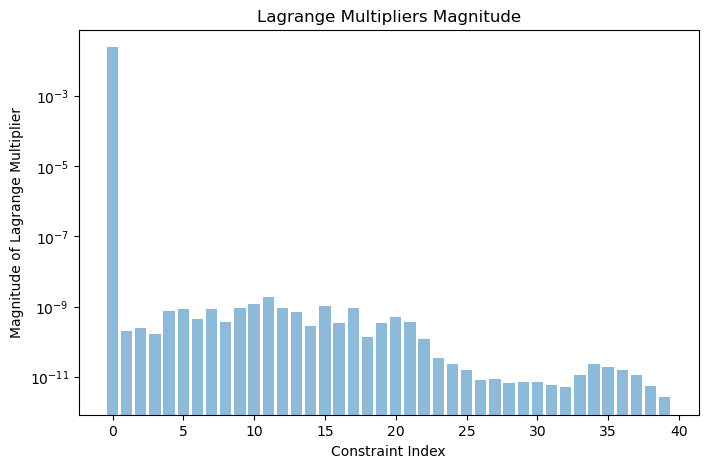

In [54]:
# Now I take the solved gcd_QCQP and finetune it with BFGS if necessary.
t1 = time.time()
gcd_final_result = gcd_QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = gcd_QCQP.current_lags, opt_params = None)
print(f"bound: {gcd_final_result[0]}, time: {time.time()-t1}s")

# Let's check for PSD-ness and constraints again

lags = gcd_QCQP.current_lags
totalA = gcd_QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"min eigenvalue: {np.min(np.real(eigenvals))}")

iChol = gcd_QCQP.current_xstar
qLocal= iChol.conj() * (Umat.conj().T @ iChol)
lLocal = 2 * iChol.conj() * eVec
con_violation = lLocal - qLocal 
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Nopt), np.real(con_violation), alpha=0.5, label='Real Part')
plt.bar(np.arange(Nopt), np.imag(con_violation), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('Constraint Violation')
plt.title('Constraint Violation in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


primar_obj = np.real(iChol.conj().T @ Bmat @ iChol + bVec.conj().T @ iChol + beta)
print(f"GCD primary objective: {primar_obj}")
print(f"GCD dual bound: {gcd_QCQP.current_dual}")

Ivec = Mfactor @ iChol
Porg = np.real(Ivec.conj().T @ Obj @ Ivec)
print(f"Objective with GCD solution: {Porg}")

# plot logscale abs(lags)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(lags)), np.abs(lags), alpha=0.5)
plt.xlabel('Constraint Index')
plt.ylabel('Magnitude of Lagrange Multiplier')
plt.title('Lagrange Multipliers Magnitude')
plt.yscale('log')
plt.show()


Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
inference error: 1.0064075637614947


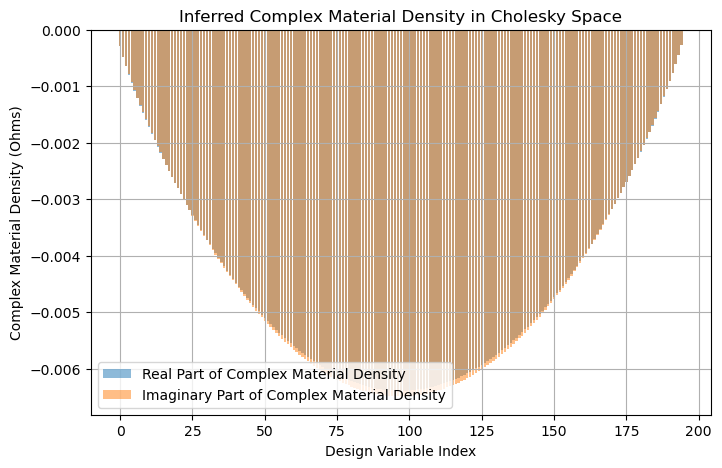

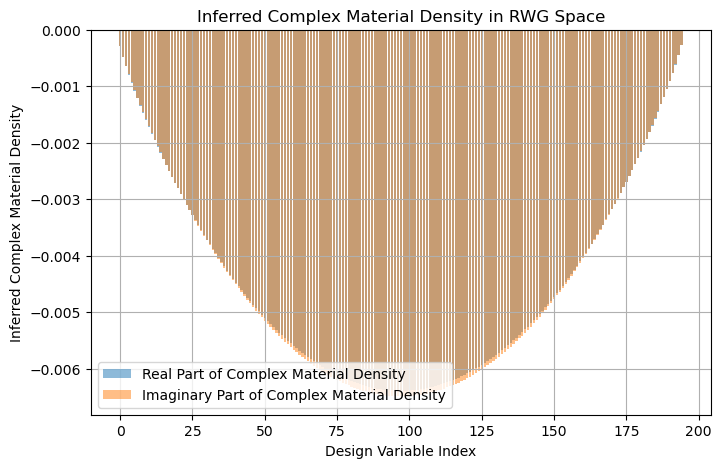

Objective for inferred material density: -1.010821e+01 W


In [51]:
# infer conductivity
Lchol = np.linalg.cholesky(Lmat).conj().T
MfactorInf = np.linalg.inv(Lchol)

# Ivec = np.linalg.solve(Ztot, Vinc) # optimal current distribution in original coordinates

iChol = Lchol @ Ivec
Z0fInf = MfactorInf.conj().T @ Z0 @ MfactorInf
VincfInf = MfactorInf.conj().T @ Vinc

Vopt = Z0fInf @ iChol
Vinf = VincfInf - Vopt
Zinff = Vinf / iChol

# Umd = 1j * np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Zmatf - np.diag(Zinff)).conj()
# Umds = Umd + Umd.conj().T
# eq4 = (iChol.conj().T @ Umds @ iChol)/(iChol.conj().T @ Zmatf @ iChol)
# print(f"eq4 value normalized by squared norm: {eq4}, expected to be close to zero for consistency with GCD solution")


print(f"Surface impedance: {Zs} Ω")

complexMaterialDensityChol = Zs / Zinff
print(f"inference error: {np.max(np.abs(complexMaterialDensityChol - 1))}")

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensityChol), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensityChol), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
diagZinf = np.diag(Zinf)
diagZmat = np.diag(Zmat)


complexMaterialDensity = diagZmat / diagZinf

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Inferred Complex Material Density')
plt.title('Inferred Complex Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

# evaluate performmance for inferred material density
ZtotInf = Z0 + Zinf
IfullInf = np.linalg.solve(ZtotInf, Vinc) # current distribution for inferred material density
PfullInf = np.real(IfullInf.conj().T @ Obj @ IfullInf) # radiated power for inferred material density
print(f"Objective for inferred material density: {PfullInf:.6e} W")


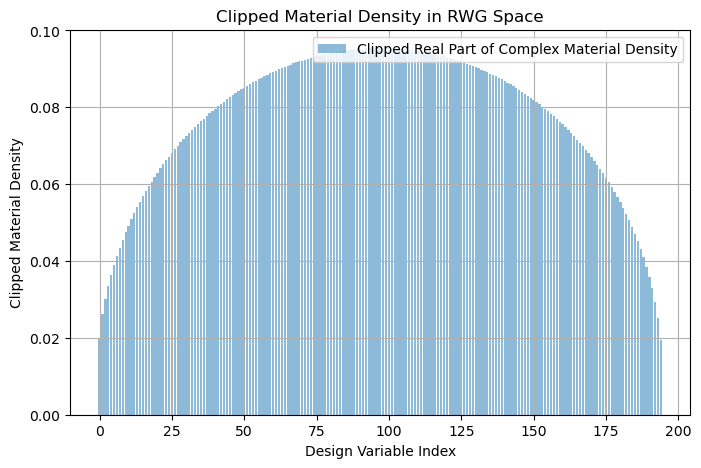

Objective for limited inferred material density: -1.3267e+00 W


In [52]:
# limit material density to be postive real [0,1]
material_density = np.sqrt(np.clip(np.abs(complexMaterialDensity), 1e-9, 1))
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

addLoss = 1/material_density
ZmatInfLim = np.diag(addLoss) @ Zmat @ np.diag(addLoss)
ZtotInfLim = Z0 + ZmatInfLim
IfullInfLim = np.linalg.solve(ZtotInfLim, Vinc) # current distribution for inferred material density
PfullInfLim = np.real(IfullInfLim.conj().T @ Obj @ IfullInfLim) # radiated power for inferred material density
print(f"Objective for limited inferred material density: {PfullInfLim:.4e} W")

np.savetxt("limited_material_density.txt", material_density, delimiter=',')